### 1. Persiapan Library dan Resource

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install gensim Sastrawi

import pandas as pd
import regex as re
import nltk
import gensim
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from gensim.models.coherencemodel import CoherenceModel
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Inisialisasi Resource
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
factory = StemmerFactory()
stemmer = factory.create_stemmer()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.0 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### 2. Definisi Fungsi Helper

In [3]:
def clean_indonesian_text(text):
    text = str(text).lower()
    text = re.sub(r'@[^\s]+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

### 3. Tahap 1: Memuat Data & Preprocessing

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/UAS/dataset.csv')
df = df.dropna(subset=['comments'])

df['cleaned_comments'] = df['comments'].apply(clean_indonesian_text)

stop_words = set(stopwords.words('indonesian'))
additional_stopwords = {'yg', 'dg', 'klo', 'aja', 'dgn', 'kok', 'ini', 'itu', 'insanee', 'sticker'}
stop_words.update(additional_stopwords)

tokenized_docs = []
for doc in df['cleaned_comments']:
    tokens = word_tokenize(doc)
    cleaned_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokenized_docs.append(cleaned_tokens)

df['tokens'] = tokenized_docs
print("Preprocessing selesai.")
print(" ")
display(df[['comments', 'cleaned_comments']])

Preprocessing selesai.
 


,comments,cleaned_comments
0,Stress,stress
1,the real fomo politik,the real fomo politik
2,INSANEEEEEEEEEE…,insanee
3,this is honestly just sad guys,this is honestly just sad guys
4,[Sticker] padahal ada canva malah milih ai,sticker padahal ada canva malah milih ai
...,...,...
824,"Nah,ide mbg itu bagus tapi pelaksananya/ekseku...",nahide mbg itu bagus tapi pelaksananyaeksekusi...
825,​ @FeriPsikopat ya karena program ambisi bukan...,ya karena program ambisi bukan program terperi...
826,Makanya guru honorer mau dibayar murah ya begi...,makanya guru honorer mau dibayar murah ya begi...
827,@TotoSt-h8f guru honorer bersertifikat mahal...,guru honorer bersertifikat mahal kok gajinya


In [5]:
# Menambahkan stemming pada token yang sudah bersih
print("Melakukan Stemming (ini mungkin memakan waktu sedikit lama)...")
def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

df['stemmed_tokens'] = df['tokens'].apply(stem_tokens)
print("Stemming selesai.")

Melakukan Stemming (ini mungkin memakan waktu sedikit lama)...
Stemming selesai.


In [6]:
df.to_csv('processed_dataset.csv', index=False)

### Evaluasi LDA dengan TF-IDF (Coherence Score)

Sekarang kita evaluasi kembali model LDA yang dilatih dengan fitur TF-IDF.

In [ ]:
# Mendefinisikan kembali dictionary dan corpus yang terhapus
dictionary = corpora.Dictionary(df['stemmed_tokens'])
corpus = [dictionary.doc2bow(doc) for doc in df['stemmed_tokens']]
num_topics = 3

# 1. Bangun model TF-IDF dari korpus BoW
tfidf = gensim.models.TfidfModel(corpus)

# 2. Ubah korpus BoW menjadi korpus TF-IDF
corpus_tfidf = tfidf[corpus]

# 3. Latih model LDA menggunakan korpus TF-IDF
lda_model_tfidf = gensim.models.LdaModel(
    corpus=corpus_tfidf,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=15
)

print("Model LDA (menggunakan TF-IDF) berhasil dilatih.")

for idx, topic in lda_model_tfidf.print_topics(-1, num_words=5):
    print(f"Topik {idx} (TF-IDF): {topic}")

Model LDA (menggunakan TF-IDF) berhasil dilatih.
Topik 0 (TF-IDF): 0.012*"guru" + 0.010*"suruh" + 0.009*"malu" + 0.009*"mbg" + 0.008*"nya"
Topik 1 (TF-IDF): 0.019*"spanduk" + 0.014*"bayar" + 0.007*"kpai" + 0.007*"anak" + 0.007*"kreatif"
Topik 2 (TF-IDF): 0.026*"miris" + 0.010*"anak" + 0.010*"banget" + 0.009*"mbg" + 0.008*"bgt"


In [ ]:
# Evaluasi LDA dengan Coherence Score menggunakan model TF-IDF yang baru
coherence_model_lda = CoherenceModel(model=lda_model_tfidf, texts=df['stemmed_tokens'], dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()

print(f"Coherence Score LDA (TF-IDF): {coherence_lda:.4f}")
print("(Semakin mendekati 1, semakin baik topik yang dihasilkan secara semantik)")

Coherence Score LDA (TF-IDF): 0.5128
(Semakin mendekati 1, semakin baik topik yang dihasilkan secara semantik)


In [ ]:
# Evaluasi LDA dengan Coherence Score (menggunakan korpus TF-IDF)
coherence_model_lda_tfidf = CoherenceModel(model=lda_model_tfidf, texts=df['tokens'], dictionary=dictionary, coherence='c_v')
coherence_lda_tfidf = coherence_model_lda_tfidf.get_coherence()

print(f"Coherence Score LDA (menggunakan TF-IDF): {coherence_lda_tfidf:.4f}")
print("(Semakin mendekati 1, semakin baik topik yang dihasilkan secara semantik)")

Coherence Score LDA (menggunakan TF-IDF): nan
(Semakin mendekati 1, semakin baik topik yang dihasilkan secara semantik)


/usr/local/lib/python3.12/dist-packages/gensim/topic_coherence/direct_confirmation_measure.py:204: RuntimeWarning: divide by zero encountered in scalar divide
  m_lr_i = np.log(numerator / denominator)
/usr/local/lib/python3.12/dist-packages/gensim/topic_coherence/indirect_confirmation_measure.py:323: RuntimeWarning: invalid value encountered in scalar divide
  return cv1.T.dot(cv2)[0, 0] / (_magnitude(cv1) * _magnitude(cv2))


### 5. Tahap 3: Text Clustering (K-Means)

In [ ]:
display(df)

,username,comments,cleaned_comments,tokens,stemmed_tokens
0,agoyogasm,Stress,stress,[stress],[stress]
1,pizernitsalep,the real fomo politik,the real fomo politik,"[the, real, fomo, politik]","[the, real, fomo, politik]"
2,qiourzzz,INSANEEEEEEEEEE…,insanee,[],[]
3,joan02879,this is honestly just sad guys,this is honestly just sad guys,"[this, honestly, just, sad, guys]","[this, honestly, just, sad, guys]"
4,glxsyy_fnyy,[Sticker] padahal ada canva malah milih ai,sticker padahal ada canva malah milih ai,"[canva, milih]","[canva, milih]"
...,...,...,...,...,...
824,@FeriPsikopat,"Nah,ide mbg itu bagus tapi pelaksananya/ekseku...",nahide mbg itu bagus tapi pelaksananyaeksekusi...,"[nahide, mbg, bagus, pelaksananyaeksekusi, nya...","[nahide, mbg, bagus, pelaksananyaeksekusi, nya..."
825,@agushandokomanasje6798,​ @FeriPsikopat ya karena program ambisi bukan...,ya karena program ambisi bukan program terperi...,"[program, ambisi, program, terperinci, rapi]","[program, ambisi, program, perinci, rapi]"
826,@TotoSt-h8f,Makanya guru honorer mau dibayar murah ya begi...,makanya guru honorer mau dibayar murah ya begi...,"[guru, honorer, dibayar, murah, modelnya]","[guru, honorer, bayar, murah, model]"
827,@firman99-99,@TotoSt-h8f guru honorer bersertifikat mahal...,guru honorer bersertifikat mahal kok gajinya,"[guru, honorer, bersertifikat, mahal, gajinya]","[guru, honorer, sertifikat, mahal, gaji]"


In [ ]:
# Menggabungkan kembali list token menjadi string agar bisa diproses TfidfVectorizer
stemmed_sentences = df['stemmed_tokens'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(stemmed_sentences)

num_clusters = 3
kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# Memperbaiki target simpan hasil cluster agar tidak menimpa kolom token
df['cluster_label'] = kmeans_model.fit_predict(tfidf_matrix)

for i in range(num_clusters):
    print(f"Cluster {i} Sample:")
    display(df[df['cluster_label'] == i]['comments'].head(3).tolist())
    print("-" * 30)

Cluster 0 Sample:


['Stress', 'the real fomo politik', 'INSANEEEEEEEEEE…']

------------------------------
Cluster 1 Sample:


['Miris', 'miris bgt gurunya', '[Sticker] gurunya miris bgtt']

------------------------------
Cluster 2 Sample:


['habis di bayar berapa tuh?',
 'Dibayar berapaa deck?',
 'aku juga ikut, itu rill ga di bayar']

------------------------------


In [ ]:
# Evaluasi K-Means dengan Silhouette Score
silhouette_avg = silhouette_score(tfidf_matrix, df['cluster_label'])

print(f"Silhouette Score K-Means: {silhouette_avg:.4f}")
print("(Skor > 0 menunjukkan pengelompokan mulai terbentuk, skor mendekati 1 sangat ideal)")

Silhouette Score K-Means: 0.0707
(Skor > 0 menunjukkan pengelompokan mulai terbentuk, skor mendekati 1 sangat ideal)


**Clustering FTC**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

def calculate_tau_entropy(probabilities):
    # Menghindari log(0)
    probabilities = np.clip(probabilities, 1e-10, 1.0)
    return -np.sum(probabilities * np.log(probabilities))

def ftc_clustering_real_data(data_matrix, max_clusters=3):
    """
    Implementasi FTC menggunakan data TF-IDF asli dari dataset.
    """
    if hasattr(data_matrix, 'toarray'):
        data_matrix_dense = data_matrix.toarray()
    else:
        data_matrix_dense = data_matrix

    n_samples = data_matrix_dense.shape[0]
    # Inisialisasi: Semua indeks dokumen dalam satu cluster
    clusters = [list(range(n_samples))]

    while len(clusters) < max_clusters:
        best_split_idx = -1
        max_entropy = -1

        for i, cluster_indices in enumerate(clusters):
            if len(cluster_indices) < 10: continue

            sub_matrix = data_matrix_dense[cluster_indices]
            centroid = np.asarray(sub_matrix.mean(axis=0))
            similarities = cosine_similarity(sub_matrix, centroid.reshape(1, -1)).flatten()

            # Normalisasi probabilitas (Softmax) untuk hitung entropy
            exp_sim = np.exp(similarities - np.max(similarities))
            probs = exp_sim / np.sum(exp_sim)
            entropy = calculate_tau_entropy(probs)

            if entropy > max_entropy:
                max_entropy = entropy
                best_split_idx = i

        if best_split_idx == -1: break

        # Pemecahan cluster terpilih menggunakan K-Means (K=2)
        to_split = clusters.pop(best_split_idx)
        sub_matrix_to_split = data_matrix_dense[to_split]

        km = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = km.fit_predict(sub_matrix_to_split)

        c1 = [to_split[j] for j in range(len(labels)) if labels[j] == 0]
        c2 = [to_split[j] for j in range(len(labels)) if labels[j] == 1]

        clusters.append(c1)
        clusters.append(c2)

    final_labels = np.zeros(n_samples)
    for cluster_id, indices in enumerate(clusters):
        for idx in indices:
            final_labels[idx] = cluster_id

    return final_labels

print("Memulai FTC pada dataset asli...")
# Menggunakan tfidf_matrix yang sudah ada di kernel state
ftc_labels = ftc_clustering_real_data(tfidf_matrix, max_clusters=3)

# Memasukkan hasil ke dataframe
df['ftc_cluster_label'] = ftc_labels.astype(int)

print("=== HASIL CLUSTERING FTC (DATA ASLI) ===")
summary = []
for i in range(int(max(ftc_labels)+1)):
    count = len(df[df['ftc_cluster_label'] == i])
    perc = (count / len(df)) * 100
    summary.append({'Cluster': i, 'Jumlah': count, 'Persentase': f"{perc:.2f}%"})

    print(f"\nCluster {i} ({count} dokumen):")
    print(df[df['ftc_cluster_label'] == i]['comments'].head(3).to_string(index=False))

display(pd.DataFrame(summary))

Memulai FTC pada dataset asli...
=== HASIL CLUSTERING FTC (DATA ASLI) ===

Cluster 0 (31 dokumen):
                       Miris
           miris bgt gurunya
[Sticker] gurunya miris bgtt

Cluster 1 (738 dokumen):
               Stress
the real fomo politik
     INSANEEEEEEEEEE…

Cluster 2 (56 dokumen):
          spanduk chatgpt
   kok spanduknya KREATIF
mana spanduk nya ai lagii


,Cluster,Jumlah,Persentase
0,0,31,3.76%
1,1,738,89.45%
2,2,56,6.79%


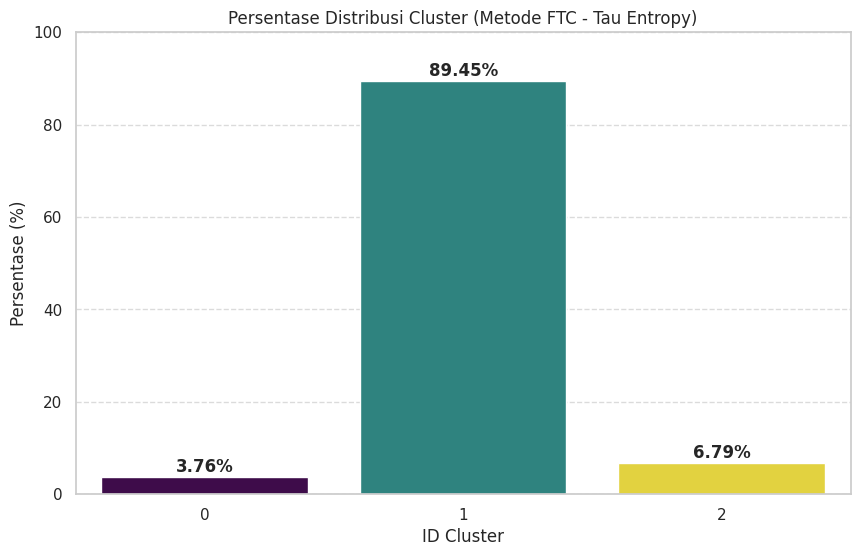

,Cluster,Jumlah Dokumen,Persentase
0,0,31,3.757576
1,1,738,89.454545
2,2,56,6.787879


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung distribusi cluster FTC
ftc_counts = df['ftc_cluster_label'].value_counts().sort_index()
ftc_percentages = (ftc_counts / len(df)) * 100

# 2. Membuat Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=ftc_percentages.index, y=ftc_percentages.values, palette='viridis', hue=ftc_percentages.index, legend=False)

# Menambahkan label persentase di atas bar
for i, v in enumerate(ftc_percentages.values):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.title('Persentase Distribusi Cluster (Metode FTC - Tau Entropy)')
plt.xlabel('ID Cluster')
plt.ylabel('Persentase (%)')
plt.ylim(0, 100) # Set limit agar skala tetap 0-100
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Menampilkan tabel ringkasan
summary_ftc = pd.DataFrame({
    'Cluster': ftc_counts.index,
    'Jumlah Dokumen': ftc_counts.values,
    'Persentase': ftc_percentages.values
})
display(summary_ftc)

In [ ]:
# 9. PROSES ELIMINASI ITERATIF KANDIDAT KLASTER BERDASARKAN EO TERKECIL

print("\n" + "="*50)
print("   PROSES ELIMINASI ITERATIF KANDIDAT KLASTER")
print("="*50)

# Membuat salinan kandidat klaster agar data asli tidak rusak
remaining_clusters = {}
for c_id, info in cluster_candidate.items():
    remaining_clusters[c_id] = {
        "terms": info["terms"],
        "docs": set(info["docs"])  # disalin sebagai set baru
    }

final_selected_clusters = []
iteration_counter = 1

# Lakukan loop eliminasi selama masih ada kandidat klaster yang memiliki dokumen
while True:
    # A. Hitung ulang f_d untuk dokumen yang tersisa di kandidat klaster saat ini
    current_all_docs = []
    for c_id, info in remaining_clusters.items():
        current_all_docs.extend(list(info["docs"]))

    if not current_all_docs:
        break # Berhenti jika tidak ada dokumen tersisa di seluruh kandidat

    current_doc_counts = {}
    for doc in current_all_docs:
        current_doc_counts[doc] = current_doc_counts.get(doc, 0) + 1

    # B. Hitung ulang nilai EO untuk setiap kandidat klaster yang tersisa
    current_eo_results = {}
    for c_id, info in remaining_clusters.items():
        if len(info["docs"]) > 0:
            eo_val = calculate_entropy_overlap(info["docs"], current_doc_counts)
            current_eo_results[c_id] = eo_val

    if not current_eo_results:
        break

    # C. Pilih klaster dengan nilai EO terkecil pada iterasi ini
    best_cluster_id = min(current_eo_results, key=current_eo_results.get)
    best_cluster_eo = current_eo_results[best_cluster_id]
    best_cluster_info = remaining_clusters[best_cluster_id]

    # Ambil dokumen yang akan dieliminasi oleh klaster ini
    eliminated_docs = list(best_cluster_info["docs"])

    # Simpan klaster yang terpilih
    final_selected_clusters.append({
        "Iterasi": iteration_counter,
        "No Cluster Asal": f"C{best_cluster_id}",
        "Frequent Term Set": f"{{{','.join(sorted(best_cluster_info['terms']))}}}",
        "Jumlah Dokumen": len(eliminated_docs),
        "EO Saat Terpilih": round(best_cluster_eo, 4)
    })

    print(f"\n[Iterasi {iteration_counter}]")
    print(f"-> Klaster Terbaik Terpilih: C{best_cluster_id} dengan Term {{{','.join(best_cluster_info['terms'])}}}")
    print(f"-> Nilai EO Terkecil pada iterasi ini: {round(best_cluster_eo, 4)}")
    print(f"-> Mengeliminasi {len(eliminated_docs)} dokumen dari pencarian berikutnya.")

    # D. Proses Eliminasi: Hapus dokumen terpilih dari seluruh kandidat klaster lainnya
    for c_id in list(remaining_clusters.keys()):
        remaining_clusters[c_id]["docs"] = remaining_clusters[c_id]["docs"].difference(set(eliminated_docs))
        # Jika kandidat klaster menjadi kosong setelah eliminasi, hapus dari list kandidat
        if len(remaining_clusters[c_id]["docs"]) == 0:
            del remaining_clusters[c_id]

    iteration_counter += 1

# 10. Menampilkan Hasil Akhir Klaster yang Lolos Seleksi Eliminasi FTC
print("\n" + "="*50)
print("          HASIL AKHIR KLASTER FINAL")
print("="*50)
df_final = pd.DataFrame(final_selected_clusters)
print(df_final.to_string(index=False))


   PROSES ELIMINASI ITERATIF KANDIDAT KLASTER

[Iterasi 1]
-> Klaster Terbaik Terpilih: C2 dengan Term {guru}
-> Nilai EO Terkecil pada iterasi ini: 7.3369
-> Mengeliminasi 43 dokumen dari pencarian berikutnya.

[Iterasi 2]
-> Klaster Terbaik Terpilih: C1 dengan Term {nya}
-> Nilai EO Terkecil pada iterasi ini: 5.663
-> Mengeliminasi 43 dokumen dari pencarian berikutnya.

[Iterasi 3]
-> Klaster Terbaik Terpilih: C3 dengan Term {mbg}
-> Nilai EO Terkecil pada iterasi ini: 7.3369
-> Mengeliminasi 87 dokumen dari pencarian berikutnya.

[Iterasi 4]
-> Klaster Terbaik Terpilih: C4 dengan Term {anak}
-> Nilai EO Terkecil pada iterasi ini: 5.8918
-> Mengeliminasi 57 dokumen dari pencarian berikutnya.

[Iterasi 5]
-> Klaster Terbaik Terpilih: C5 dengan Term {demo}
-> Nilai EO Terkecil pada iterasi ini: 0.0
-> Mengeliminasi 31 dokumen dari pencarian berikutnya.

          HASIL AKHIR KLASTER FINAL
 Iterasi No Cluster Asal Frequent Term Set  Jumlah Dokumen  EO Saat Terpilih
       1            

### 6. Tahap 4: Named Entity Recognition (NER)

### 6.1. Definisi Struktur Data
Di sini kita mendefinisikan kelas `Entity` untuk menyimpan hasil temuan dan `Token` untuk menyimpan informasi kata beserta fitur-fitur linguistiknya.

In [ ]:
# Menambahkan parameter on_bad_lines='skip' untuk melewati baris yang formatnya tidak konsisten
dataset = pd.read_csv("/content/gojek review.csv", on_bad_lines='skip')

print(f"Dataset berhasil dimuat dengan {len(dataset)} baris.")
display(dataset.head())

# Perbaikan: Gunakan kurung siku [] untuk mengakses kolom, bukan ()
# Catatan: Pastikan jumlah baris dataset sesuai dengan df jika ingin memasukkannya ke df['new_content']
df_new_content = dataset['content']

print("\nContoh isi kolom content:")
print(df_new_content.head())

Dataset berhasil dimuat dengan 194043 baris.


/tmp/ipykernel_4650/416963783.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("/content/gojek review.csv", on_bad_lines='skip')


,userName,content,score,at,appVersion
0,Yuga Edit,akun gopay saya di blok,1,2022-01-21 10:52:12,4.9.3
1,ff burik,Lambat sekali sekarang ini bosssku apk gojek g...,3,2021-11-30 15:40:38,4.9.3
2,Anisa Suci Rahmayuliani,Kenapa sih dari kemarin sy buka aplikasi gojek...,4,2021-11-29 22:58:12,4.9.3
3,naoki yakuza,Baru download gojek dan hape baru trus ditop u...,1,2022-09-03 15:21:17,4.9.3
4,Trio Sugianto,Mantap,5,2022-01-15 10:05:27,4.9.3



Contoh isi kolom content:
0                              akun gopay saya di blok
1    Lambat sekali sekarang ini bosssku apk gojek g...
2    Kenapa sih dari kemarin sy buka aplikasi gojek...
3    Baru download gojek dan hape baru trus ditop u...
4                                               Mantap
Name: content, dtype: object


In [ ]:
import re
from dataclasses import dataclass
from typing import List, Dict, Optional

@dataclass
class Entity:
    text: str
    label: str
    start: int
    end: int

    def __repr__(self):
        return f"[{self.label}] {self.text}"

@dataclass
class Token:
    text: str
    start: int
    end: int
    contextual: Optional[str] = None
    morphological: Optional[str] = None
    pos: Optional[str] = None
    ne_label: Optional[str] = None

### 6.2. Kamus Fitur (Dictionaries)
Kamus ini digunakan untuk mencocokkan kata dengan peran tertentu, seperti awalan nama orang (PPRE) atau kata depan lokasi (LOPP).

In [ ]:
CONTEXTUAL_FEATURES = {
    "PPRE": ["prof.", "dr.", "pak", "k.h.", "presiden"],
    "PTIT": ["menteri", "sekjen"],
    "OPRE": ["pt.", "universitas", "dinas", "kementerian", "badan", "kemendikdasmen"],
    "OPOS": ["ketua", "direktur", "kepala"],
    "LPRE": ["kota", "propinsi", "provinsi", "kabupaten", "jalan", "jl."],
    "LOPP": ["di", "ke", "dari"]
}

POS_DICTIONARY = {
    "PREP": ["di", "ke", "dari", "pada", "dalam", "untuk", "oleh"],
    "CONJ": ["dan", "atau", "tetapi", "serta"],
    "VERB": ["pergi", "bertemu", "membahas", "mengatakan"],
    "NOUN": ["kemarin", "hari", "tahun"]
}

### 6.3. Logika Ekstraksi & Aturan (Rules)
Fungsi-fungsi ini bertugas menganalisis bentuk kata (morfologi) dan menerapkan aturan if-then untuk menentukan label entitas.

In [ ]:
def assign_morphological(text):
    if text.isupper(): return "UpperCase"
    if text.istitle(): return "TitleCase"
    if text.islower(): return "LowerCase"
    return "Other"

def assign_contextual(text):
    text_l = text.lower()
    for feat, words in CONTEXTUAL_FEATURES.items():
        if text_l in words: return feat
    return None

def apply_rules(tokens):
    n = len(tokens)
    for i in range(n):
        # Aturan untuk Orang
        if tokens[i].contextual in ["PPRE", "PTIT"] and i+1 < n:
            if tokens[i+1].morphological in ["TitleCase", "UpperCase"]:
                tokens[i+1].ne_label = "PERSON"
        # Aturan untuk Lokasi
        if tokens[i].contextual == "LOPP" and i+1 < n:
            if tokens[i+1].morphological == "TitleCase":
                tokens[i+1].ne_label = "LOC"
        # Aturan untuk Organisasi
        if tokens[i].contextual == "OPRE":
            tokens[i].ne_label = "ORG"
        if tokens[i].text.startswith('@'):
            tokens[i].ne_label = "PERSON"

def extract_entities(tokens):
    entities, i = [], 0
    while i < len(tokens):
        if tokens[i].ne_label:
            label, start, end, parts = tokens[i].ne_label, tokens[i].start, tokens[i].end, [tokens[i].text]
            j = i + 1
            while j < len(tokens) and tokens[j].ne_label == label:
                end, parts.append(tokens[j].text)
                j += 1
            entities.append(Entity(" ".join(parts), label, start, end))
            i = j
        else: i += 1
    return entities

def indo_rule_based_ner(text):
    if not isinstance(text, str) or not text.strip(): return []
    raw_matches = re.finditer(r'@[\w.]+|\b\w+\b|[^\w\s]', text)
    tokens = [Token(m.group(), m.start(), m.end()) for m in raw_matches if m.group().strip()]
    for t in tokens:
        t.contextual, t.morphological = assign_contextual(t.text), assign_morphological(t.text)
    apply_rules(tokens)
    return extract_entities(tokens)

### 6.4. Eksekusi pada DataFrame
Menjalankan fungsi NER ke seluruh data dan menampilkan log hasil ekstraksi.

In [ ]:
# Mengambil sampel data agar pemrosesan tidak terlalu lama
test_sample = dataset.head(1000).copy()

print(f"Memproses NER pada {len(test_sample)} baris sampel dari dataset baru...")
test_sample['entities'] = test_sample['content'].apply(indo_rule_based_ner)

# Menampilkan hasil ekstraksi yang ditemukan
print(f"\n{'='*60}\n{'LOG HASIL NER (SAMPEL DATA BARU)':^60}\n{'='*60}")

# Filter baris yang memiliki setidaknya satu entitas yang terdeteksi
results = test_sample[test_sample['entities'].map(len) > 0]

if results.empty:
    print("Tidak ada entitas yang terdeteksi pada sampel ini.")
else:
    for idx, row in results.head(15).iterrows():
        print(f"Baris {idx:<4} | Entitas: {row['entities']}")
        print(f"Teks: {str(row['content'])[:80]}...")
        print("-"*60)

print(f"\nTotal baris dengan entitas ditemukan: {len(results)}")

In [ ]:
print("Memproses NER pada dataset...")
df['entities'] = df['comments'].apply(indo_rule_based_ner)

print(f"\n{'='*60}\n{'LOG HASIL NER (SAMPEL)':^60}\n{'='*60}")
samples = df[df['entities'].map(len) > 0].head(10)
for idx, row in samples.iterrows():
    print(f"Baris {idx:<4} | Entitas: {row['entities']}")
    print(f"Teks: {row['comments'][:80]}...")
    print("-"*60)

In [ ]:
# Grafik 1: LDA Topics
# Menggunakan lda_model_tfidf karena model sebelumnya sudah diganti
for idx in range(num_topics):
    topic_words = lda_model_tfidf.show_topic(idx, topn=10)
    words, weights = zip(*topic_words)
    plt.figure()
    sns.barplot(x=list(weights), y=list(words), palette='viridis', hue=list(words), legend=False)
    plt.title(f"Topik {idx} (LDA TF-IDF)")
    plt.show()

# Grafik 2: Cluster Distribution
cluster_counts = df['cluster_label'].value_counts().sort_index()
plt.figure()
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='Set2', hue=cluster_counts.index, legend=False)
plt.title("Distribusi Cluster (K-Means)")
plt.show()

# Grafik 3: NER Entity Frequency
# Memastikan list all_labels diisi dari kolom 'entities' yang sudah diproses
all_labels = [ent.label for ents in df['entities'] for ent in ents]
entity_counts = Counter(all_labels)
if entity_counts:
    plt.figure()
    sns.barplot(x=list(entity_counts.values()), y=list(entity_counts.keys()), palette='magma', hue=list(entity_counts.keys()), legend=False)
    plt.title("Frekuensi Entitas (NER Result)")
    plt.show()